# XAI vs No XAI Comparison - Boltz-2 Binding Affinity (MGYP) — Extended with Baselines

Comparing the effect of explainable AI (XAI) guidance on molecule optimization performance using Boltz-2 binding affinity predictions for the MGYP protein target.

This extended version also includes REINVENT, GraphGA, and GP-BO baseline molecules scored with Boltz-2.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import random

random.seed(42)
np.random.seed(42)

In [2]:
# Define paths
TRACE_ROOT = Path("../../data/results/boltz2_hard")
BASELINE_CSV = Path("../../data/results/baselines_boltz-2/baseline_molecules_boltz2_pred.csv")
ZERO_SHOT_CSV = Path("../../data/results/zero_shot/boltz-2/combined_boltz2_zero-shot_molecules_results.csv")
FIGURE_DIR = Path("./figures")

# Set to False to hide legend (for combined figures with shared legend)
SHOW_LEGEND = True

# Optional: restrict to a subset, e.g. ["with_explanation", "no_explanation"]
INTERVENTION_DIRS = ["with_explanation", "no_explanation", "no_sequence"]

# Intervention mapping for display names
INTERVENTION_MAP = {
    "with_explanation": "Full explanation",
    "no_explanation": "No explanation",
    "no_sequence": "No sequence",
}

## Loading Data

In [3]:
def load_trace(p: Path) -> dict:
    """Load conversation from JSON file."""
    with open(p) as f:
        return json.load(f)


def extract_iteration_score_table(conversation: dict, max_it: int = 49) -> pd.DataFrame:
    """Extract iteration and score from conversation trace."""
    trace = conversation.get("trace", [])
    
    if len(trace) == 0:
        return pd.DataFrame({
            "iteration": range(max_it),
            "score": [np.nan] * max_it,
        })
    
    df = pd.DataFrame(trace)
    
    # Use original_score if available, otherwise use score
    if "original_score" in df.columns:
        df = df[["iteration", "original_score"]].rename(columns={"original_score": "score"})
    else:
        df = df[["iteration", "score"]]
    
    # Fill missing iterations with NaN
    max_it = max(df["iteration"].max(), max_it)
    missing_its = set(range(1, max_it + 1)) - set(df["iteration"])
    
    if missing_its:
        missing_df = pd.DataFrame({
            "iteration": list(missing_its),
            "score": [np.nan] * len(missing_its),
        })
        df = pd.concat([df, missing_df], ignore_index=True)
    
    return df


def load_agent_traces_from_dirs(
    trace_root: Path,
    intervention_map: dict,
    intervention_dirs: list[str] | None = None,
    file_pattern: str = "*.json",
) -> pd.DataFrame:
    """Load all agent traces from intervention subfolders.

    Each subfolder name is used as `intervention`, and files are sorted
    and numbered 1..N as `repeat` within that intervention.
    """
    dfs = []

    if intervention_dirs is None:
        dirs = sorted([d for d in trace_root.iterdir() if d.is_dir()])
    else:
        dirs = [trace_root / d for d in intervention_dirs]

    for intervention_dir in dirs:
        if not intervention_dir.exists() or not intervention_dir.is_dir():
            continue

        intervention = intervention_dir.name
        json_files = sorted(intervention_dir.glob(file_pattern))

        for repeat, trace_file in enumerate(json_files, start=1):
            conversation = load_trace(trace_file)
            df = extract_iteration_score_table(conversation)
            df["intervention"] = intervention
            df["repeat"] = repeat
            dfs.append(df)

    if not dfs:
        return pd.DataFrame(columns=["model", "intervention", "repeat", "iteration", "score"])

    agent_df = pd.concat(dfs, ignore_index=True)
    agent_df["model"] = agent_df["intervention"].map(intervention_map)
    return agent_df


def load_baseline_csv(csv_path: Path) -> pd.DataFrame:
    """Load baseline molecules scored with Boltz-2 from CSV.
    
    The CSV has: model, replicate, iteration, smiles, affinity_probability_binary, affinity_pred_value
    We use affinity_probability_binary as the score (higher is better, matches agent score).
    """
    baseline_df = pd.read_csv(csv_path)
    baseline_df = baseline_df.rename(columns={"affinity_probability_binary": "score"})
    # Align columns with agent data
    baseline_df["intervention"] = baseline_df["model"]
    baseline_df["repeat"] = baseline_df["replicate"]
    return baseline_df[["model", "intervention", "repeat", "iteration", "score"]]

def load_zero_shot_csv(csv_path: Path) -> pd.DataFrame:
    """Load zero-shot molecules scored with Boltz-2 from CSV.
    
    The CSV has: target,run,prompt_style,iteration,smiles,affinity_probability_binary,affinity_pred_value
    We use affinity_probability_binary as the score (higher is better, matches agent score).
    """
    zero_shot_df = pd.read_csv(csv_path)
    zero_shot_df = zero_shot_df.rename(columns={"affinity_probability_binary": "score"})
    # Align columns with agent data
    zero_shot_df = zero_shot_df[zero_shot_df["target"].isin(["mgyp"])]
    zero_shot_df["intervention"] = zero_shot_df["prompt_style"]
    zero_shot_df["model"] = "zero_shot_" + zero_shot_df["prompt_style"]
    zero_shot_df["repeat"] = zero_shot_df["run"]
    return zero_shot_df[["model", "intervention", "repeat", "iteration", "score"]]

# Load agent traces from intervention folders
agent_df = load_agent_traces_from_dirs(
    TRACE_ROOT,
    INTERVENTION_MAP,
    INTERVENTION_DIRS,
    file_pattern="*.json",
)

# Load baseline CSV
baseline_df = load_baseline_csv(BASELINE_CSV)

# Load zero-shot CSV
zero_shot_df = load_zero_shot_csv(ZERO_SHOT_CSV)

# Combine into single DataFrame
df = pd.concat(
    [agent_df[["model", "intervention", "repeat", "iteration", "score"]],
     baseline_df,
     zero_shot_df],
    ignore_index=True,
)
print(df.tail())

print(f"Total rows: {len(df)}")
print("Agent runs per intervention:")
print(agent_df.groupby("intervention")["repeat"].nunique())

print("Models:")
print(df.groupby("model")["repeat"].nunique())

                  model intervention  repeat  iteration     score
1489  zero_shot_generic      generic       3         46  0.141744
1490  zero_shot_generic      generic       3         47  0.328402
1491  zero_shot_generic      generic       3         48  0.137451
1492  zero_shot_generic      generic       3         49  0.152549
1493  zero_shot_generic      generic       3         50  0.190988
Total rows: 1494
Agent runs per intervention:
intervention
no_explanation      5
no_sequence         5
with_explanation    5
Name: repeat, dtype: int64
Models:
model
Full explanation     5
GP-BO                3
GraphGA              3
No explanation       5
No sequence          5
REINVENT             3
zero_shot_generic    3
zero_shot_task       3
Name: repeat, dtype: int64


---
## Best-so-far Progression Plot

> **Note on baselines:** With only 50 oracle calls, REINVENT / GraphGA / GP-BO never complete their initialization phase (default population sizes: GraphGA=120, GP-BO=340). These curves therefore represent **random sampling from a drug-like (ZINC) library** scored with Boltz-2, not actual algorithm optimization. Treat them as a random-search lower bound, not as representative of these algorithms' capabilities.

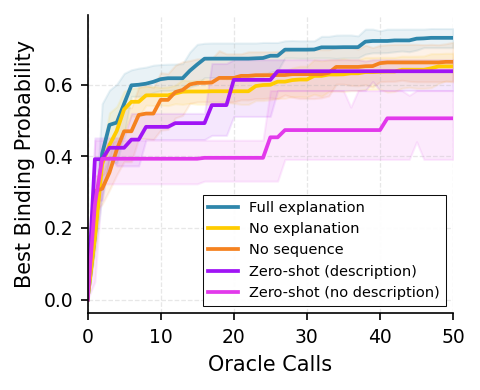

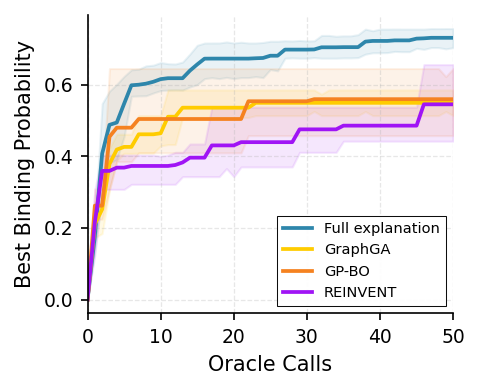

PosixPath('figures/xai_vs_baselines_boltz2_mgyp.pdf')

In [4]:
# Reusable best-so-far plotting utility
MAX_ITER = 50

# Generic colors are assigned in the exact order of selected_display_models
GENERIC_COLORS = [
    '#2E86AB',  # blue
    #'#00a69d',  # teal
    '#ffcc00',  # yellow
    '#f58220',  # orange
    #'#E84855',  # red  
    '#A014F5',  # violet
    '#E239EB',  # magenta
    
    '#91114F',  # plum
    '#B983D9',  # rose
]

# Canonical display names and how they map to df['model'] values
DISPLAY_TO_MODEL = {
    'Full explanation': 'Full explanation',
    'No explanation': 'No explanation',
    'No sequence': 'No sequence',
    'Zero-shot (no description)': 'zero_shot_generic',
    'Zero-shot (description)': 'zero_shot_task',
    'REINVENT': 'REINVENT',
    'GraphGA': 'GraphGA',
    'GP-BO': 'GP-BO',
}

def plot_best_so_far(
    df_input: pd.DataFrame,
    selected_display_models: list[str],
    output_filename: str,
    show_legend: bool = True,
    max_iter: int = MAX_ITER,
    #ylim: tuple[float, float] = (0.0, 1.0),
    figsize: tuple[float, float] = (7, 4),
    label_fontsize: int = 13,
    tick_fontsize: int = 11,
    linewidth: float = 2.5,
):
    """Plot mean best-so-far curves with 95% CI in the order provided."""
    missing = [m for m in selected_display_models if m not in DISPLAY_TO_MODEL]
    if missing:
        raise ValueError(f'Unknown display model(s): {missing}')

    display_to_canonical = {m: DISPLAY_TO_MODEL[m] for m in selected_display_models}
    canonical_to_display = {v: k for k, v in display_to_canonical.items()}
    canonical_models = list(display_to_canonical.values())

    subset = df_input[df_input['model'].isin(canonical_models)].copy()
    if subset.empty:
        raise ValueError('No data available for selected models.')

    subset['score_filled'] = subset['score'].fillna(0.0)
    subset['best_so_far'] = (
        subset.sort_values('iteration')
        .groupby(['model', 'repeat'])['score_filled']
        .cummax()
    )

    df_plot = (
        subset[subset['iteration'] <= max_iter]
        .pivot_table(index='iteration', columns=['model', 'repeat'], values='best_so_far')
        .reindex(range(0, max_iter + 1))
        .ffill()
        .fillna(0.0)
        .melt(ignore_index=False)
        .reset_index()
    )

    palette = {
        model: GENERIC_COLORS[i % len(GENERIC_COLORS)]
        for i, model in enumerate(canonical_models)
    }

    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    sns.lineplot(
        data=df_plot,
        x='iteration',
        y='value',
        hue='model',
        hue_order=canonical_models,
        palette=palette,
        errorbar=('ci', 95),
        err_kws={'alpha': 0.1},
        linewidth=linewidth,
        ax=ax,
    )

    ax.set_xlabel('Oracle Calls', fontsize=label_fontsize, fontweight='normal')
    ax.set_ylabel('Best Binding Probability', fontsize=label_fontsize, fontweight='normal')
    ax.set_xlim(0, max_iter)
    #ax.set_ylim(*ylim)
    #ax.set_yticks([i * 0.1 for i in range(0, 8)])
    ax.tick_params(labelsize=tick_fontsize)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        labels = [canonical_to_display.get(label, label) for label in labels]
        legend = ax.legend(
            handles,
            labels,
            #title='Model',
            frameon=True,
            fancybox=False,
            shadow=False,
            framealpha=0.95,
            edgecolor='black',
            loc='lower right',
            #title_fontsize=8,
            fontsize=7
        )
        legend.get_frame().set_linewidth(0.5)
    else:
        legend_obj = ax.get_legend()
        if legend_obj is not None:
            legend_obj.remove()

    plt.tight_layout()
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    out_path = FIGURE_DIR / output_filename
    plt.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    return out_path

# Shared order for summaries/tables in other cells
legend_order = [
    'Full explanation',
    'No explanation',
    'No sequence',
    'Zero-shot (no description)',
    'Zero-shot (description)',
    'REINVENT',
    'GraphGA',
    'GP-BO',
]

# Compact settings to match the IC50 compact_kwargs style
COMPACT_KWARGS = dict(
    figsize=(3.3, 2.7),
    label_fontsize=10,
    tick_fontsize=9,
    linewidth=1.8,
)

# Plot 1: XAI + zero-shot
plot_best_so_far(
    df_input=df,
    selected_display_models=[
        'Full explanation',
        'No explanation',
        'No sequence',
        'Zero-shot (description)',
        'Zero-shot (no description)',
    ],
    output_filename='xai_vs_zeroshot_boltz2_mgyp.pdf',
    show_legend=SHOW_LEGEND,
    max_iter=50,
    **COMPACT_KWARGS,
 )

# Plot 2: Full explanation + baselines
plot_best_so_far(
    df_input=df,
    selected_display_models=[
        'Full explanation',
        'GraphGA',
        'GP-BO',
        'REINVENT',
    ],
    output_filename='xai_vs_baselines_boltz2_mgyp.pdf',
    show_legend=SHOW_LEGEND,
    max_iter=50,
    **COMPACT_KWARGS,
 )

---
## AUC Top-1 over 50 Iterations

In [5]:
def bootstrap_ci(data, n_bootstrap=10000, ci=0.95):
    """Compute bootstrap 95% CI for the mean."""
    data = data.dropna()
    if len(data) < 2:
        return np.nan, np.nan
    result = stats.bootstrap(
        (data.values,),
        statistic=np.mean,
        n_resamples=n_bootstrap,
        confidence_level=ci,
        random_state=42
    )
    return result.confidence_interval.low, result.confidence_interval.high


def compute_auc_top1(group_df, max_oracle_calls=50):
    """Compute AUC of top-1 (best) score vs oracle calls from a dataframe group.
    
    Uses trapezoidal integration (same as PMO benchmark).
    
    Args:
        group_df: DataFrame with 'score' and 'iteration' columns for a single run
        max_oracle_calls: Maximum number of oracle calls (default 50)
    
    Returns:
        AUC value normalized to [0, 1]
    """
    sorted_df = group_df.sort_values('iteration')
    
    best_score = 0.0
    best_at_call = {}
    
    for _, row in sorted_df.iterrows():
        oracle_call = int(row['iteration'])
        score = float(row['score']) if not np.isnan(row['score']) else 0.0
        
        if oracle_call > max_oracle_calls:
            break
        
        if score > best_score:
            best_score = score
        
        best_at_call[oracle_call] = best_score
    
    if not best_at_call:
        return 0.0
    
    oracle_calls = sorted(best_at_call.keys())
    
    # Compute AUC using trapezoidal integration
    auc = 0.0
    prev_call = 0
    prev_best = 0.0
    
    for call in oracle_calls:
        auc += (call - prev_call) * (best_at_call[call] + prev_best) / 2
        prev_call = call
        prev_best = best_at_call[call]
    
    # Extend to max_oracle_calls with the last value
    auc += (max_oracle_calls - prev_call) * prev_best
    
    # Normalize by max_oracle_calls to get average best-so-far score
    return auc / max_oracle_calls


# Compute AUC Top-1 for each model/repeat
MAX_ORACLE_CALLS = 50

auc_records = []
for (model, repeat), group in df.groupby(['model', 'repeat']):
    auc = compute_auc_top1(group, MAX_ORACLE_CALLS)
    auc_records.append({
        'model': model,
        'repeat': repeat,
        'auc_top1': auc
    })

auc_df = pd.DataFrame(auc_records)

# Summarize by model with bootstrap CI
auc_summary_rows = []
for model, group in auc_df.groupby('model'):
    values = group['auc_top1']
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    ci_low_dist = mean_val - ci_low
    ci_high_dist = ci_high - mean_val
    auc_summary_rows.append({
        "Model": model,
        "Mean AUC Top-1": mean_val,
        "CI 95% -": ci_low_dist,
        "CI 95% +": ci_high_dist,
        "N": len(values),
    })

# Sort in legend order
auc_summary = (
    pd.DataFrame(auc_summary_rows)
    .set_index("Model")
    .reindex(legend_order)
    .round(3)
)

print(f"AUC Top-1 over {MAX_ORACLE_CALLS} iterations with 95% Bootstrap CI")
auc_summary

AUC Top-1 over 50 iterations with 95% Bootstrap CI


,Mean AUC Top-1,CI 95% -,CI 95% +,N
Model,,,,
Full explanation,0.650,0.028,0.030,5.0
No explanation,0.581,0.052,0.023,5.0
No sequence,0.589,0.046,0.066,5.0
Zero-shot (no description),NaN,NaN,NaN,NaN
Zero-shot (description),NaN,NaN,NaN,NaN
REINVENT,0.435,0.024,0.047,3.0
GraphGA,0.509,0.018,0.034,3.0
GP-BO,0.518,0.061,0.104,3.0


Parsed rows: 238 from 5 files
Rows with valid prediction + metrics: 232


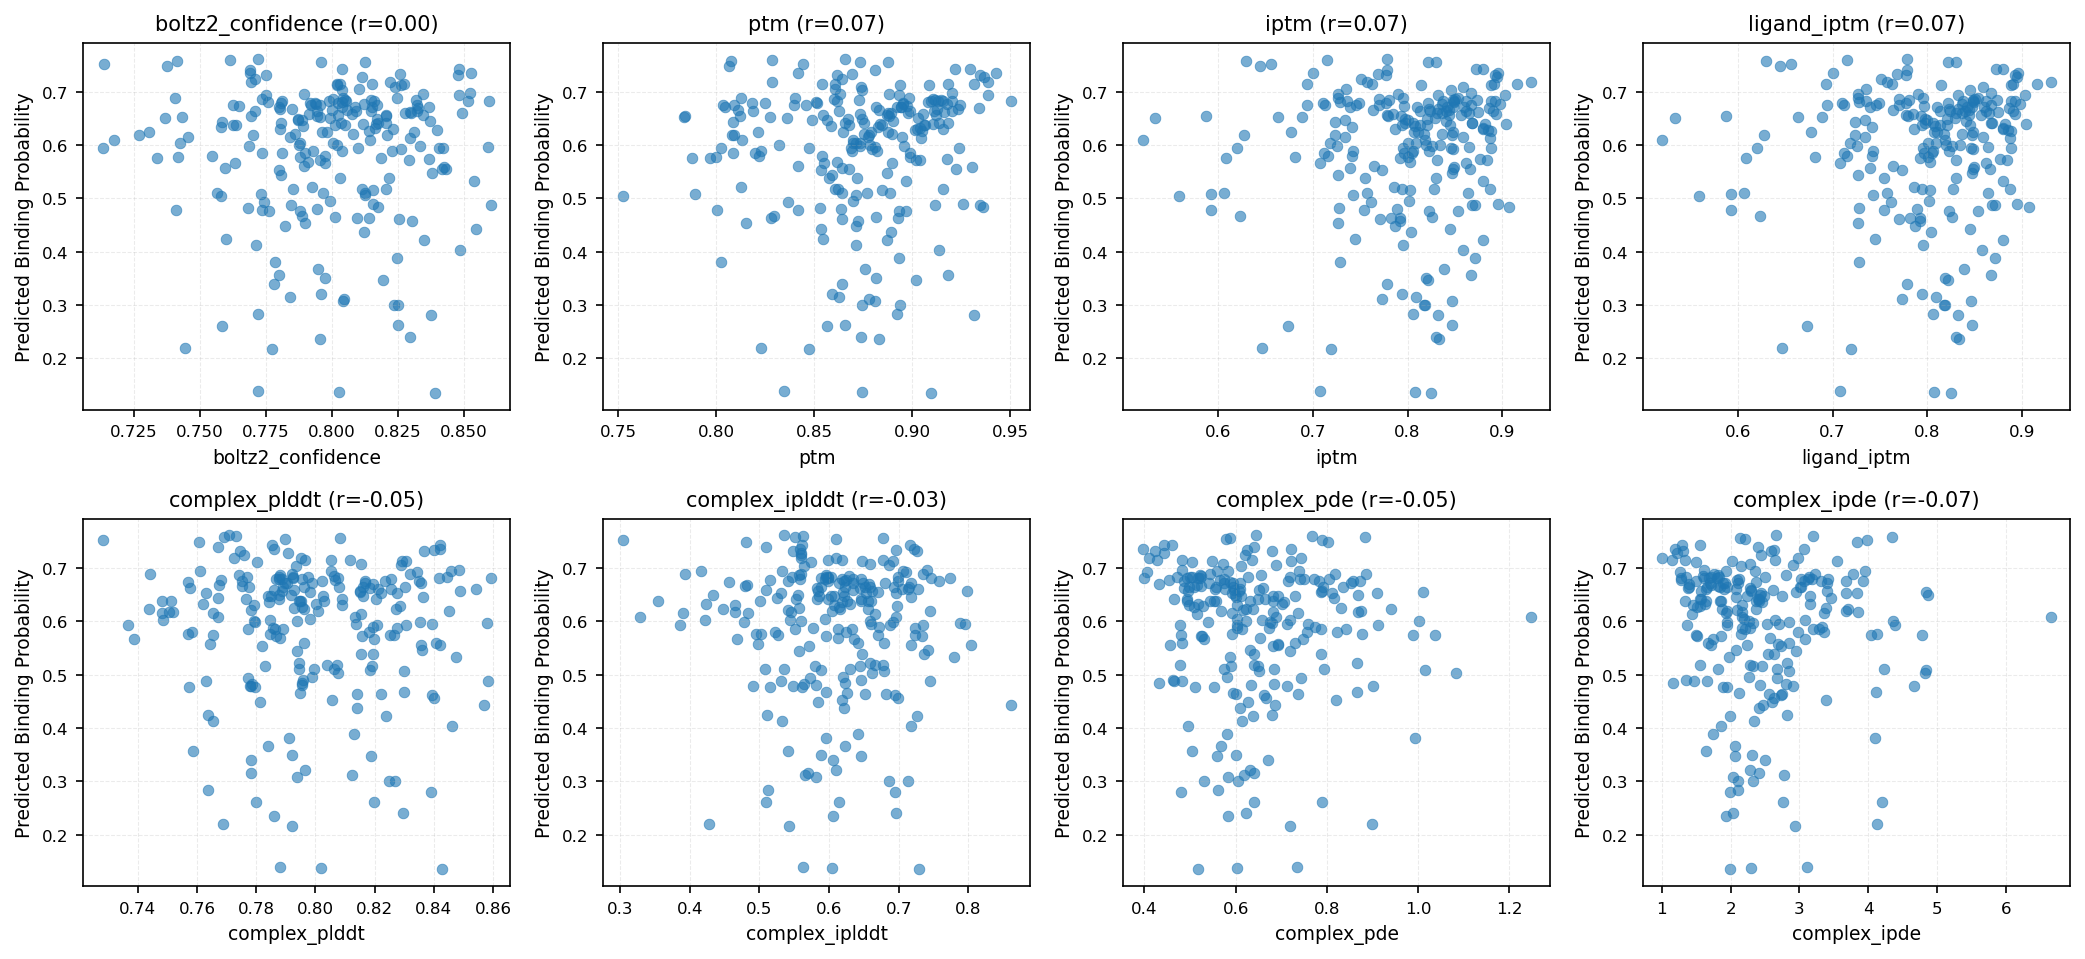

Saved: figures/boltz2_confidence_metrics_vs_predicted_scatter.pdf
Mean predicted binding probability: 0.5843879310344829
Mean boltz2_confidence: 0.7992760504201679
Mean ptm: 0.8736995798319327
Mean iptm: 0.7979537815126049
Mean ligand_iptm: 0.7979537815126049
Mean complex_plddt: 0.7996058823529412
Mean complex_iplddt: 0.6101214285714286
Mean complex_pde: 0.6466361344537815
Mean complex_ipde: 2.4813478991596636


In [6]:
import re

# Parse confidence block from post-initial Human messages in with_explanation runs
WITH_EXPLANATION_DIR = TRACE_ROOT / "with_explanation"
CONFIDENCE_OUTPUT = FIGURE_DIR / "boltz2_confidence_metrics_vs_predicted_scatter.pdf"

METRIC_KEYS = [
    ("confidence_score", "boltz2_confidence"),
    ("ptm", "ptm"),
    ("iptm", "iptm"),
    ("ligand_iptm", "ligand_iptm"),
    ("complex_plddt", "complex_plddt"),
    ("complex_iplddt", "complex_iplddt"),
    ("complex_pde", "complex_pde"),
    ("complex_ipde", "complex_ipde"),
]

PRED_RE = re.compile(r"Predicted Binding Probability:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")
FALLBACK_PRED_RE = re.compile(r"original_affinity_probability_binary:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")
ITER_RE = re.compile(r"Iteration:\s*(\d+)\s*/")

def _extract_float(pattern: re.Pattern, text: str):
    m = pattern.search(text)
    return float(m.group(1)) if m else np.nan

def _extract_metric(text: str, key: str):
    pattern = re.compile(rf"{re.escape(key)}:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")
    return _extract_float(pattern, text)

def parse_confidence_records(conversation: list, file_name: str) -> list[dict]:
    records = []
    human_seen = 0

    for msg_idx, msg in enumerate(conversation):
        if not isinstance(msg, dict) or msg.get("role") != "HumanMessage":
            continue

        human_seen += 1
        if human_seen == 1:
            # Skip initial task/setup message
            continue

        content = msg.get("content", "")
        if not isinstance(content, str) or "Confidence Scores:" not in content:
            continue

        pred = _extract_float(PRED_RE, content)
        if np.isnan(pred):
            pred = _extract_float(FALLBACK_PRED_RE, content)

        row = {
            "file": file_name,
            "message_index": msg_idx,
            "iteration": _extract_float(ITER_RE, content),
            "predicted_binding_probability": pred,
        }

        for raw_key, out_key in METRIC_KEYS:
            row[out_key] = _extract_metric(content, raw_key)

        records.append(row)

    return records

rows = []
for trace_file in sorted(WITH_EXPLANATION_DIR.glob("*.json")):
    conv = load_trace(trace_file).get("conversation", [])
    if isinstance(conv, list):
        rows.extend(parse_confidence_records(conv, trace_file.name))

confidence_df = pd.DataFrame(rows)
print(f"Parsed rows: {len(confidence_df)} from {confidence_df['file'].nunique() if not confidence_df.empty else 0} files")

if confidence_df.empty:
    raise ValueError("No confidence-score records found in with_explanation conversations.")

# Keep rows with a valid prediction and at least one confidence metric
metric_cols = [col for _, col in METRIC_KEYS]
valid_mask = confidence_df["predicted_binding_probability"].notna() & confidence_df[metric_cols].notna().any(axis=1)
plot_df = confidence_df[valid_mask].copy()
print(f"Rows with valid prediction + metrics: {len(plot_df)}")

nrows, ncols = 2, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 6.5), dpi=150)
axes = axes.flatten()

for i, metric in enumerate(metric_cols):
    ax = axes[i]
    sub = plot_df[[metric, "predicted_binding_probability"]].dropna()
    sns.scatterplot(
        data=sub,
        x=metric,
        y="predicted_binding_probability",
        alpha=0.6,
        s=26,
        edgecolor=None,
        ax=ax,
    )

    if len(sub) >= 2:
        r = sub[metric].corr(sub["predicted_binding_probability"])
        ax.set_title(f"{metric} (r={r:.2f})", fontsize=10)
    else:
        ax.set_title(f"{metric} (insufficient data)", fontsize=10)

    ax.set_xlabel(metric, fontsize=9)
    ax.set_ylabel("Predicted Binding Probability", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.5)

for ax in axes[len(metric_cols):]:
    ax.axis("off")

plt.tight_layout()
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(CONFIDENCE_OUTPUT, format="pdf", bbox_inches="tight", dpi=300)
plt.show()

print(f"Saved: {CONFIDENCE_OUTPUT}")

print(f"Mean predicted binding probability: {confidence_df['predicted_binding_probability'].mean()}")
print(f"Mean boltz2_confidence: {confidence_df['boltz2_confidence'].mean()}")
print(f"Mean ptm: {confidence_df['ptm'].mean()}")
print(f"Mean iptm: {confidence_df['iptm'].mean()}")
print(f"Mean ligand_iptm: {confidence_df['ligand_iptm'].mean()}")
print(f"Mean complex_plddt: {confidence_df['complex_plddt'].mean()}")
print(f"Mean complex_iplddt: {confidence_df['complex_iplddt'].mean()}")
print(f"Mean complex_pde: {confidence_df['complex_pde'].mean()}")
print(f"Mean complex_ipde: {confidence_df['complex_ipde'].mean()}")